# DATE2 实验6：四模型单变量敏感性分析

每次只改变一个变量，并在HMoE、Mixtral、MoDSE和Switchtrans四个模型上比较：
`Static-NoPF`、`Dynamic-NoPF`、`Dynamic-NaivePF`和最终`MemDomain`。

判定只在**同一模型、同一变量值**内部进行：MemDomain周期最低，Static-NoPF周期最高，
Dynamic-NoPF不慢于Static-NoPF。不同变量值之间不要求保持这一排序。


In [11]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scalesim.memory.memdomain_experiment import workload_digest
ROOT=Path.cwd().resolve().parent if Path.cwd().name=='fig' else Path.cwd().resolve()
OUT=ROOT/'outputs/DATE2';FIG=ROOT/'fig/DATE2';FIG.mkdir(parents=True,exist_ok=True)
PUBLIC=['Static-NoPF','Static-NaivePF','Dynamic-NoPF','Dynamic-NaivePF','MemDomain']
FINAL_INTERNAL='MemDomain-'+'Safe'
def public_rows(frame):
    q=frame[frame.baseline.isin(['Static-NoPF','Static-NaivePF','Dynamic-NoPF',
                                 'Dynamic-NaivePF',FINAL_INTERNAL])].copy()
    q['baseline']=q.baseline.replace({FINAL_INTERNAL:'MemDomain'})
    assert set(q.baseline)==set(PUBLIC)
    return q
def current_matrix(suite,stem):
    config=ROOT/'configs/MoE/DATE2'/suite/f'{stem}.json'
    output=OUT/suite/f'{stem}.csv'
    assert config.exists(),config
    assert output.exists(),f'Missing output: {output}'
    frame=pd.read_csv(output)
    expected=workload_digest(json.loads(config.read_text(encoding='utf-8')))
    assert set(frame.workload_hash)=={expected},f'Stale output: {output}'
    return frame

SCHEMES=['Static-NoPF','Dynamic-NoPF','Dynamic-NaivePF','MemDomain']
MODELS=['HMoE','Mixtral','MoDSE','Switchtrans']
COLORS={'Static-NoPF':'#A0A0A0','Dynamic-NoPF':'#4C78A8',
        'Dynamic-NaivePF':'#72B7B2','MemDomain':'#59A14F'}
LABELS={'Static-NoPF':'Static','Dynamic-NoPF':'Dynamic',
        'Dynamic-NaivePF':'Dynamic-PF','MemDomain':'MemDomain'}
VALUE_ORDER={
 'expert_count':['4','8','16'],
 'token_count':['32','128','256','512'],
 'top_k':['1','2'],
 'expert_parallel':['1','2'],
 'routing_severity':['balanced','light','high'],
 'routing_seed':[f'{severity}_seed{seed}' for severity in ('light','high')
                 for seed in range(40,45)]}
rows=[]
for config in sorted((ROOT/'configs/MoE/DATE2/robustness_factorial').glob('*.json')):
    payload=json.loads(config.read_text(encoding='utf-8'));sweep=payload['sweep']
    q=current_matrix('robustness_factorial',config.stem).copy()
    q['baseline']=q.baseline.replace({FINAL_INTERNAL:'MemDomain'})
    q=q[q.baseline.isin(SCHEMES)].copy()
    q['variable']=sweep['variable'];q['value']=str(sweep['value']);q['model']=sweep['model']
    rows.append(q)
d=pd.concat(rows,ignore_index=True)
assert d.groupby(['variable','value','model']).size().eq(4).all()
assert d.groupby(['variable','value']).model.nunique().eq(4).all()
assert len(d)==96*4
wide=d.pivot(index=['variable','value','model'],columns='baseline',values='total_cycles')
contract=pd.DataFrame(index=wide.index)
contract['MemDomain best']=wide.MemDomain.eq(wide[SCHEMES].min(axis=1))
contract['Static worst']=wide['Static-NoPF'].eq(wide[SCHEMES].max(axis=1))
contract['Dynamic <= Static']=wide['Dynamic-NoPF'].le(wide['Static-NoPF'])
display(contract.sum().to_frame('passing groups'))
assert contract.all().all()
print('All 96 model-value groups satisfy the requested within-group contract.')


,passing groups
MemDomain best,96
Static worst,96
Dynamic <= Static,96


All 96 model-value groups satisfy the requested within-group contract.


In [12]:
def variable_table(variable):
    z=wide.loc[variable].reset_index()
    z['Dynamic reduction (%)']=(1-z['Dynamic-NoPF']/z['Static-NoPF'])*100
    z['MemDomain reduction (%)']=(1-z.MemDomain/z['Static-NoPF'])*100
    z['MemDomain strict best']=z.MemDomain.lt(
        z[['Static-NoPF','Dynamic-NoPF','Dynamic-NaivePF']].min(axis=1))
    order={value:index for index,value in enumerate(VALUE_ORDER[variable])}
    z['_order']=z.value.map(order)
    return z.sort_values(['model','_order']).drop(columns='_order')

def plot_variable(variable,title,filename):
    values=VALUE_ORDER[variable];z=wide.loc[variable]
    fig,axes=plt.subplots(1,4,figsize=(18,4.8),sharey=False)
    width=.19;x=np.arange(len(values))
    for ax,model in zip(axes,MODELS):
        m=z.xs(model,level='model').reindex(values)
        for index,scheme in enumerate(SCHEMES):
            bars=ax.bar(x+(index-1.5)*width,m[scheme],width,
                        color=COLORS[scheme],label=LABELS[scheme])
            if scheme=='MemDomain':
                ax.bar_label(bars,labels=[f'{int(v):,}' for v in m[scheme]],
                             padding=2,fontsize=7,rotation=90)
        ax.set_xticks(x,values,rotation=25 if len(values)>4 else 0,ha='right' if len(values)>4 else 'center')
        ax.set_title(model);ax.set_xlabel(title);ax.set_ylabel('Total cycles (lower is better)')
        ax.grid(axis='y',alpha=.2)
    handles=[plt.Rectangle((0,0),1,1,color=COLORS[s]) for s in SCHEMES]
    fig.legend(handles,[LABELS[s] for s in SCHEMES],loc='upper center',ncol=4,
               frameon=False,bbox_to_anchor=(.5,1.01))
    fig.suptitle(f'Exp6 sensitivity: {title}',y=1.10,fontsize=14)
    plt.tight_layout(rect=(0,0,1,.90));plt.savefig(FIG/filename,bbox_inches='tight');plt.show()
    table=variable_table(variable)
    display(table[['model','value',*SCHEMES,'Dynamic reduction (%)',
                   'MemDomain reduction (%)','MemDomain strict best']].round(3))
    assert (table.MemDomain<=table[SCHEMES].min(axis=1)).all()
    assert (table['Static-NoPF']>=table[SCHEMES].max(axis=1)).all()
    assert (table['Dynamic-NoPF']<=table['Static-NoPF']).all()
    return table


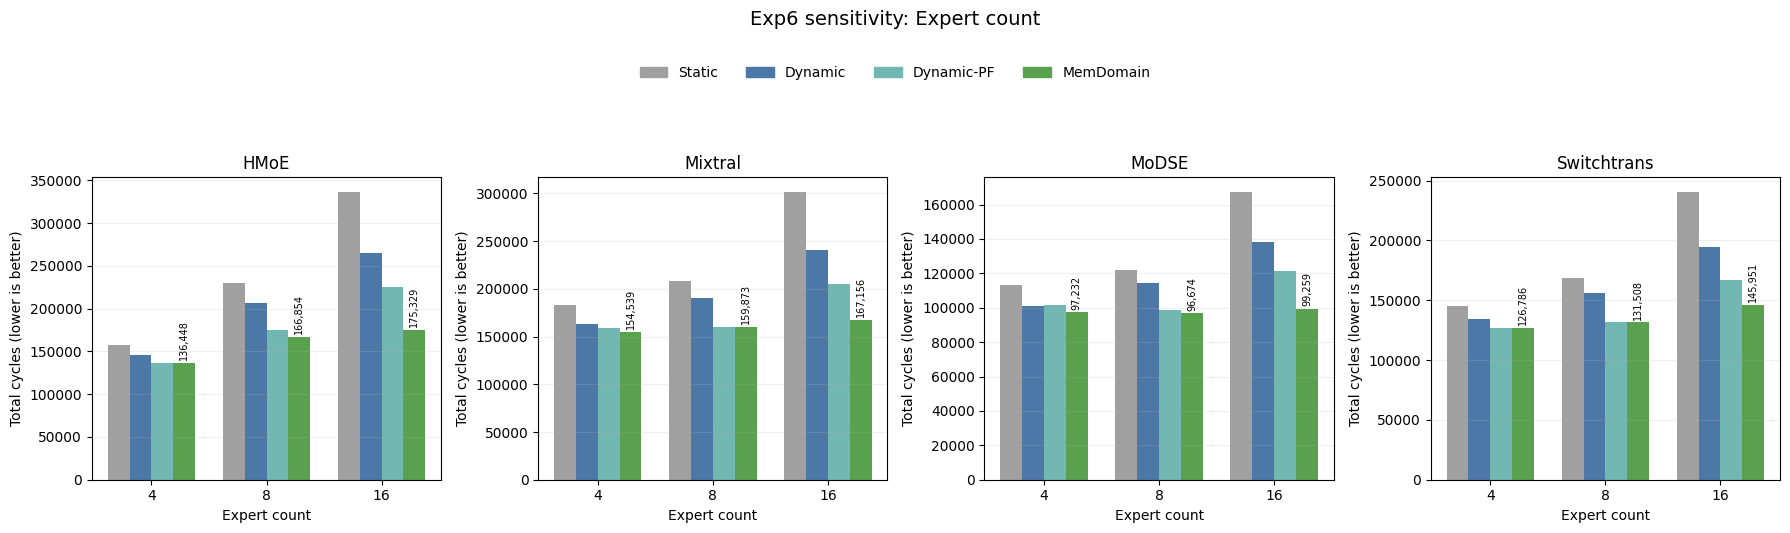

baseline,model,value,Static-NoPF,Dynamic-NoPF,Dynamic-NaivePF,MemDomain,Dynamic reduction (%),MemDomain reduction (%),MemDomain strict best
4,HMoE,4,157676,146147,136748,136448,7.312,13.463,True
8,HMoE,8,230257,206973,174577,166854,10.112,27.536,True
0,HMoE,16,336755,265208,225395,175329,21.246,47.936,True
5,Mixtral,4,182660,163569,158468,154539,10.452,15.395,True
9,Mixtral,8,208257,190861,159873,159873,8.353,23.233,False
1,Mixtral,16,301774,240612,205006,167156,20.267,44.609,True
6,MoDSE,4,112969,100784,101449,97232,10.786,13.930,True
10,MoDSE,8,121758,114302,98718,96674,6.124,20.602,True
2,MoDSE,16,167450,138411,121370,99259,17.342,40.723,True
7,Switchtrans,4,145218,134588,126786,126786,7.320,12.693,False


In [13]:
expert_count=plot_variable('expert_count','Expert count','exp6_expert_count.pdf')


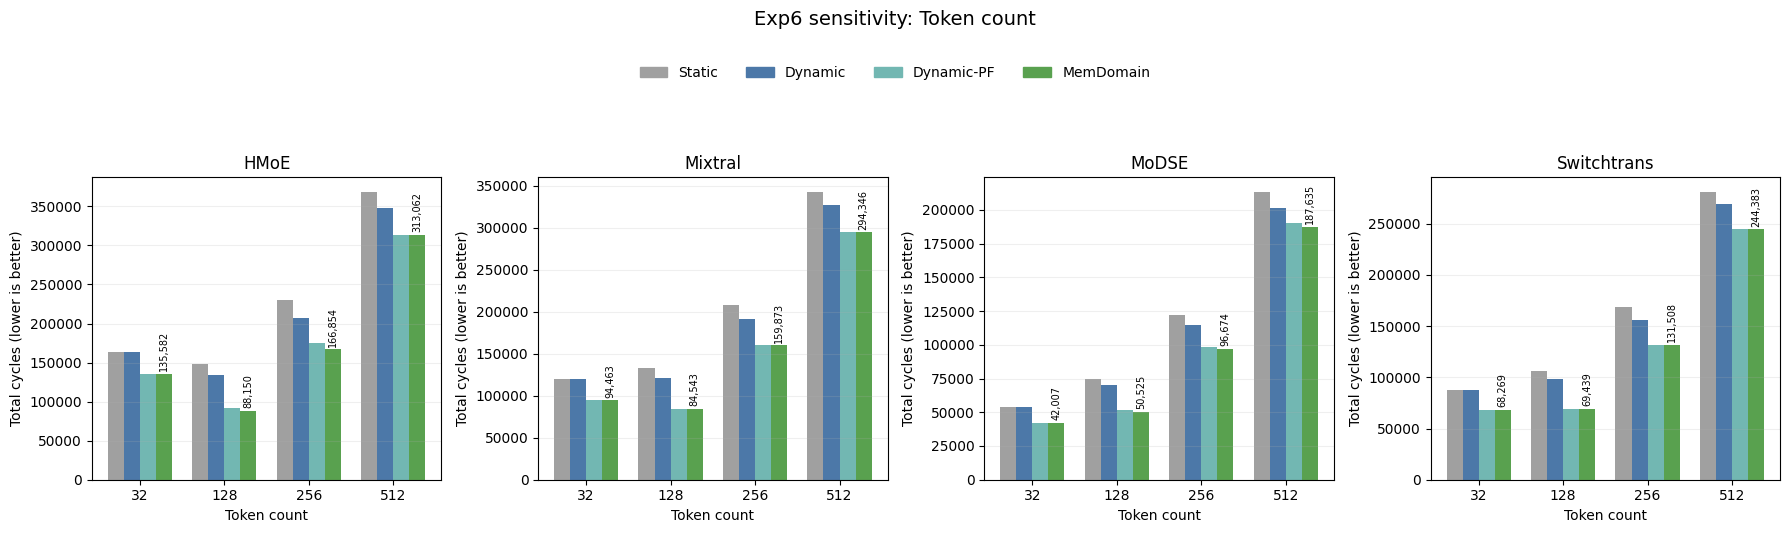

baseline,model,value,Static-NoPF,Dynamic-NoPF,Dynamic-NaivePF,MemDomain,Dynamic reduction (%),MemDomain reduction (%),MemDomain strict best
8,HMoE,32,163427,163427,135582,135582,0.000,17.038,False
0,HMoE,128,148087,133561,92407,88150,9.809,40.474,True
4,HMoE,256,230257,206973,174577,166854,10.112,27.536,True
12,HMoE,512,368742,348403,313062,313062,5.516,15.100,False
9,Mixtral,32,119641,119641,94463,94463,0.000,21.045,False
1,Mixtral,128,132927,121495,84543,84543,8.600,36.399,False
5,Mixtral,256,208257,190861,159873,159873,8.353,23.233,False
13,Mixtral,512,342730,326879,294346,294346,4.625,14.117,False
10,MoDSE,32,54196,54196,42007,42007,0.000,22.491,False
2,MoDSE,128,74369,70101,51329,50525,5.739,32.062,True


In [14]:
token_count=plot_variable('token_count','Token count','exp6_token_count.pdf')


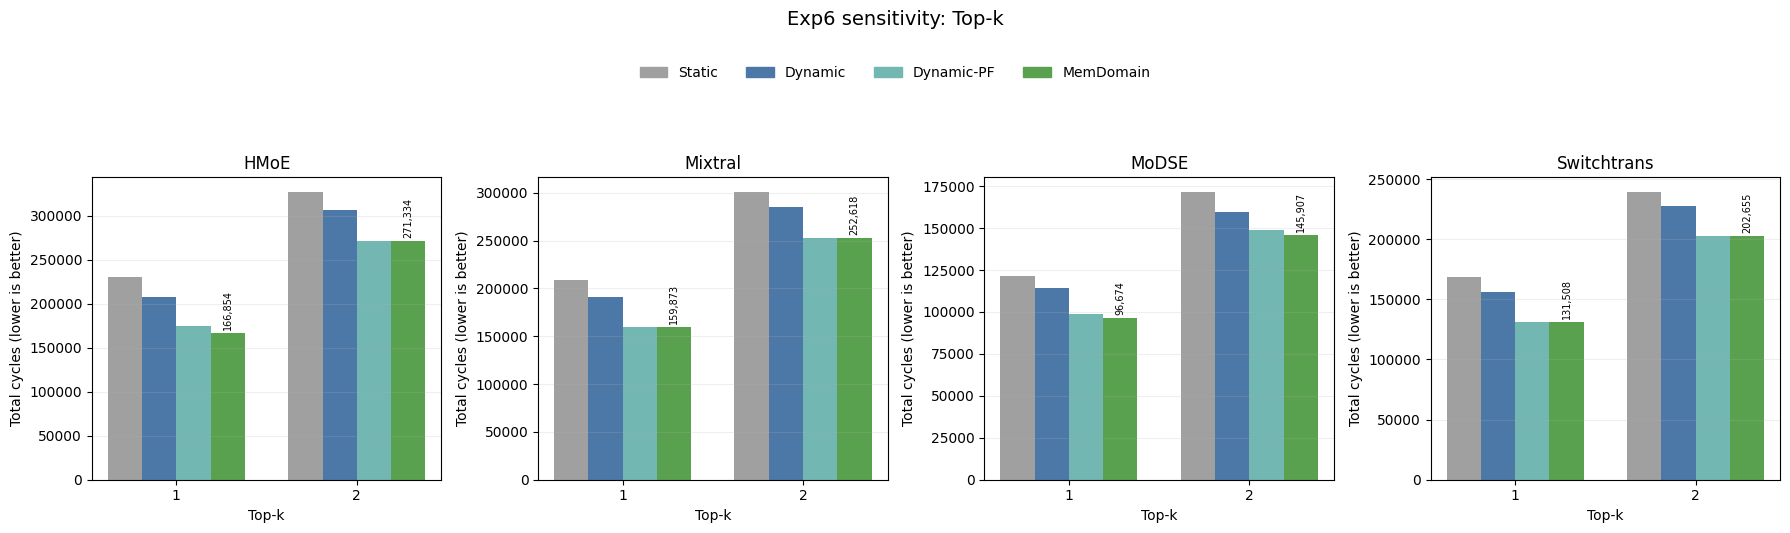

baseline,model,value,Static-NoPF,Dynamic-NoPF,Dynamic-NaivePF,MemDomain,Dynamic reduction (%),MemDomain reduction (%),MemDomain strict best
0,HMoE,1,230257,206973,174577,166854,10.112,27.536,True
4,HMoE,2,327014,306675,271334,271334,6.220,17.027,False
1,Mixtral,1,208257,190861,159873,159873,8.353,23.233,False
5,Mixtral,2,301002,285151,252618,252618,5.266,16.074,False
2,MoDSE,1,121758,114302,98718,96674,6.124,20.602,True
6,MoDSE,2,171704,159653,148664,145907,7.018,15.024,True
3,Switchtrans,1,168372,156084,131508,131508,7.298,21.894,False
7,Switchtrans,2,239519,227479,202655,202655,5.027,15.391,False


In [15]:
top_k=plot_variable('top_k','Top-k','exp6_top_k.pdf')


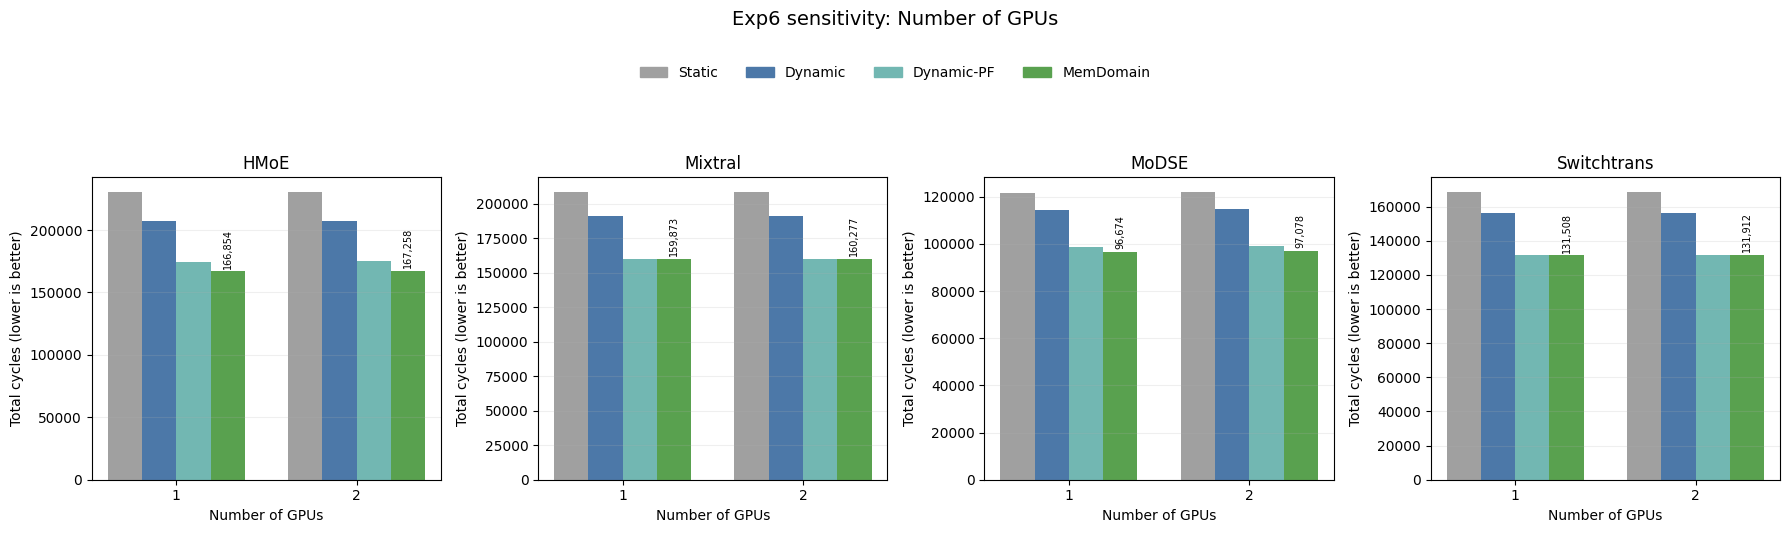

baseline,model,value,Static-NoPF,Dynamic-NoPF,Dynamic-NaivePF,MemDomain,Dynamic reduction (%),MemDomain reduction (%),MemDomain strict best
0,HMoE,1,230257,206973,174577,166854,10.112,27.536,True
4,HMoE,2,230661,207377,174981,167258,10.094,27.488,True
1,Mixtral,1,208257,190861,159873,159873,8.353,23.233,False
5,Mixtral,2,208661,191265,160277,160277,8.337,23.188,False
2,MoDSE,1,121758,114302,98718,96674,6.124,20.602,True
6,MoDSE,2,122162,114706,99122,97078,6.103,20.533,True
3,Switchtrans,1,168372,156084,131508,131508,7.298,21.894,False
7,Switchtrans,2,168776,156488,131912,131912,7.281,21.842,False


In [16]:
expert_parallel=plot_variable('expert_parallel','Number of GPUs','exp6_expert_parallel.pdf')


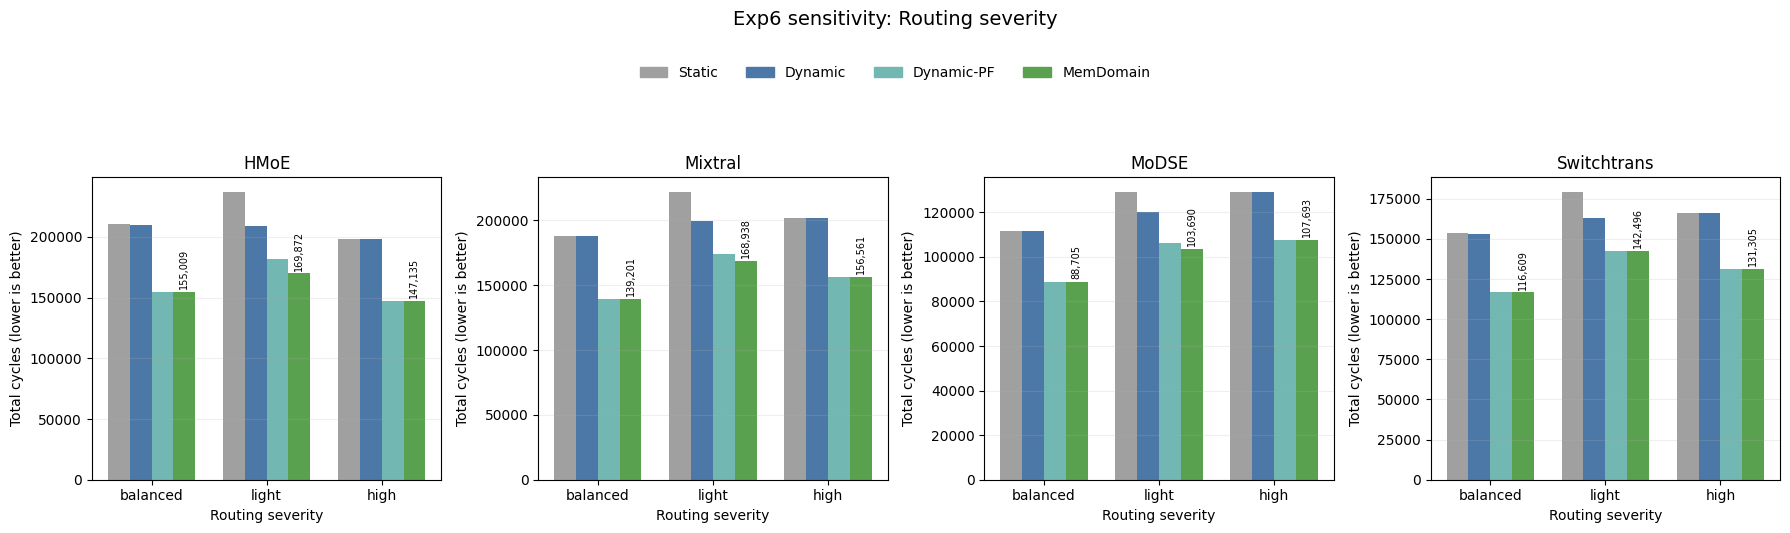

baseline,model,value,Static-NoPF,Dynamic-NoPF,Dynamic-NaivePF,MemDomain,Dynamic reduction (%),MemDomain reduction (%),MemDomain strict best
0,HMoE,balanced,210689,209993,155009,155009,0.330,26.428,False
8,HMoE,light,237219,209239,181539,169872,11.795,28.390,True
4,HMoE,high,198486,198486,147561,147135,0.000,25.871,True
1,Mixtral,balanced,187585,187585,139201,139201,0.000,25.793,False
9,Mixtral,light,222047,199118,173663,168938,10.326,23.918,True
5,Mixtral,high,201697,201697,156561,156561,0.000,22.378,False
2,MoDSE,balanced,111745,111745,88705,88705,0.000,20.618,False
10,MoDSE,light,129242,119966,106202,103690,7.177,19.771,True
6,MoDSE,high,128927,128927,107693,107693,0.000,16.470,False
3,Switchtrans,balanced,153473,153146,116609,116609,0.213,24.020,False


In [17]:
routing_severity=plot_variable('routing_severity','Routing severity','exp6_routing_severity.pdf')


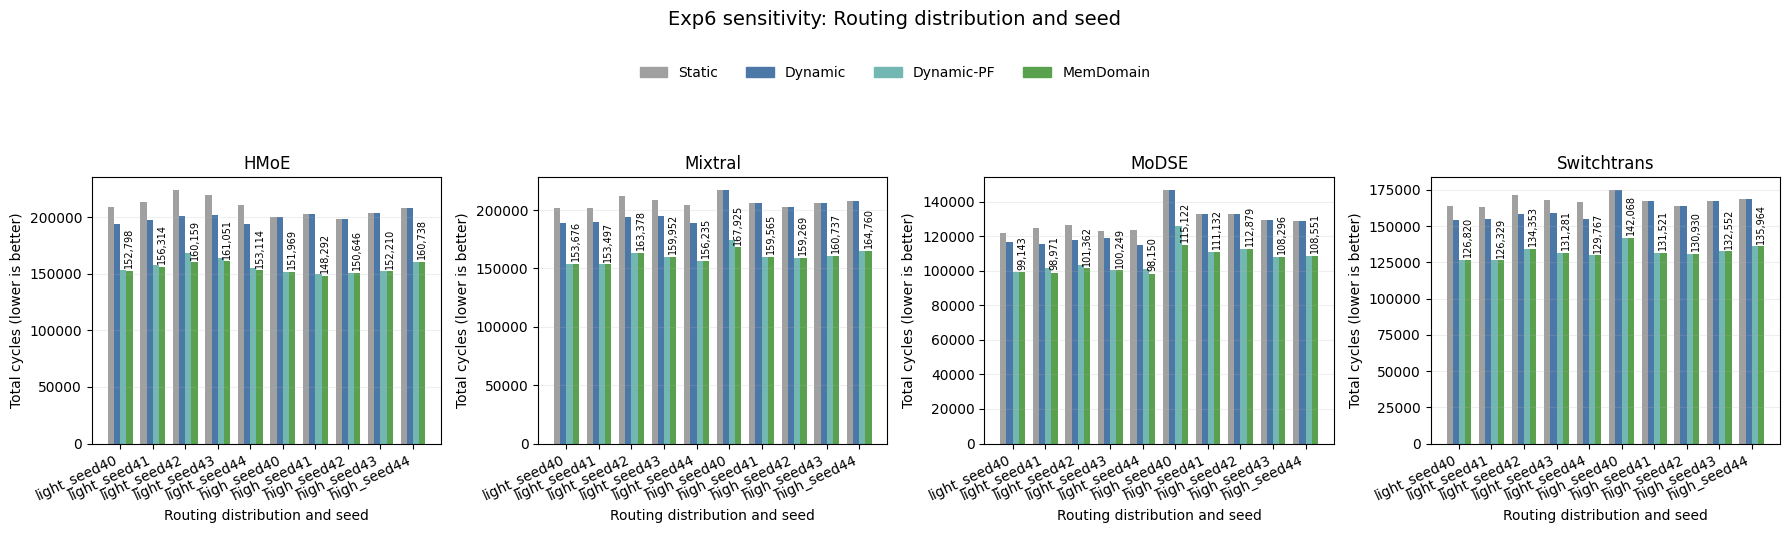

baseline,model,value,Static-NoPF,Dynamic-NoPF,Dynamic-NaivePF,MemDomain,Dynamic reduction (%),MemDomain reduction (%),MemDomain strict best
20,HMoE,light_seed40,209189,193874,153509,152798,7.321,26.957,True
24,HMoE,light_seed41,213285,197240,157605,156314,7.523,26.711,True
28,HMoE,light_seed42,224070,201431,168390,160159,10.104,28.523,True
32,HMoE,light_seed43,219859,201857,164179,161051,8.188,26.748,True
36,HMoE,light_seed44,211072,193957,155392,153114,8.109,27.459,True
0,HMoE,high_seed40,200003,200003,151969,151969,0.000,24.017,False
4,HMoE,high_seed41,202997,202997,150175,148292,0.000,26.949,True
8,HMoE,high_seed42,198533,198533,150646,150646,0.000,24.120,False
12,HMoE,high_seed43,203588,203588,152210,152210,0.000,25.236,False
16,HMoE,high_seed44,208164,208164,160738,160738,0.000,22.783,False


In [18]:
routing_seed=plot_variable('routing_seed','Routing distribution and seed','exp6_routing_seed.pdf')


## 判读规则

- 每张图只分析一个变量；四个子图分别对应四个模型；
- 每个变量值内部验证MemDomain最好、Static最差、Dynamic优于Static；
- 跨变量值的绝对周期变化反映工作量、路由压力或通信开销变化，应单独解释，
  不要求较大变量值的MemDomain一定优于较小变量值的Static。
